In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Dataset 1 UVA.csv", sep=";")

In [9]:
df.head


<bound method NDFrame.head of                              id geslacht geboortedatum postcode woonplaats  \
0      5cb9a38136dd1336b9c528d1        m         0-0-0      NaN        NaN   
1      5cb9a38336dd1336b9c537f3        v         0-0-0      NaN        NaN   
2      5cb9a38236dd1336b9c52f07        m         0-0-0      NaN        NaN   
3      5cb9a38236dd1336b9c53694        v         0-0-0      NaN        NaN   
4      5cb9a38636dd1336b9c54e48        m         0-0-0      NaN        NaN   
...                         ...      ...           ...      ...        ...   
19995  5c6bed6d5798a7942837bfcd        m    19-09-1947  3815 MN        NaN   
19996  5c6bed715798a7942837dbb0        m    07-09-1986  7553 lg        NaN   
19997  5c6bed725798a7942837e588        m           NaN   2412vf        NaN   
19998  5c6bed6b5798a7942837b3c3        m    15-03-1945  5632 PM        NaN   
19999  5c6bed715798a7942837dd89        v    27-03-1997  6721 GV        NaN   

                                 

In [13]:
df['geboortedatum'] = df['geboortedatum'].replace(
    ['0', '0-0-0', '0000-00-00'],
    pd.NA
)

In [15]:
df['geboortedatum'].isna().mean() * 100

39.96

In [17]:
df.head

<bound method NDFrame.head of                              id geslacht geboortedatum postcode woonplaats  \
0      5cb9a38136dd1336b9c528d1        m          <NA>      NaN        NaN   
1      5cb9a38336dd1336b9c537f3        v          <NA>      NaN        NaN   
2      5cb9a38236dd1336b9c52f07        m          <NA>      NaN        NaN   
3      5cb9a38236dd1336b9c53694        v          <NA>      NaN        NaN   
4      5cb9a38636dd1336b9c54e48        m          <NA>      NaN        NaN   
...                         ...      ...           ...      ...        ...   
19995  5c6bed6d5798a7942837bfcd        m    19-09-1947  3815 MN        NaN   
19996  5c6bed715798a7942837dbb0        m    07-09-1986  7553 lg        NaN   
19997  5c6bed725798a7942837e588        m           NaN   2412vf        NaN   
19998  5c6bed6b5798a7942837b3c3        m    15-03-1945  5632 PM        NaN   
19999  5c6bed715798a7942837dd89        v    27-03-1997  6721 GV        NaN   

                                 

In [21]:
df = df.rename(columns={
    'geslacht': 'gender',
    'geboortedatum': 'birth_date',
    'postcode': 'postcode',
    'woonplaats': 'city',
    'interesses': 'interests'
})

Gender analysis

In [25]:
df['gender'].value_counts(dropna=False)

gender
v          11018
m           8493
o            409
Mevrouw       57
De Heer       23
Name: count, dtype: int64

In [27]:
df['gender'] = df['gender'].str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'v': 'female',
    'mevrouw': 'female',
    'm': 'male',
    'de heer': 'male',
    'o': 'other'
})

In [29]:
df['gender'].value_counts(dropna=False)

gender
female    11075
male       8516
other       409
Name: count, dtype: int64

In [31]:
df['gender'].value_counts(normalize=True)

gender
female    0.55375
male      0.42580
other     0.02045
Name: proportion, dtype: float64

In [35]:
from datetime import datetime

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
today = pd.to_datetime('today')

df['age'] = (today - df['birth_date']).dt.days // 365

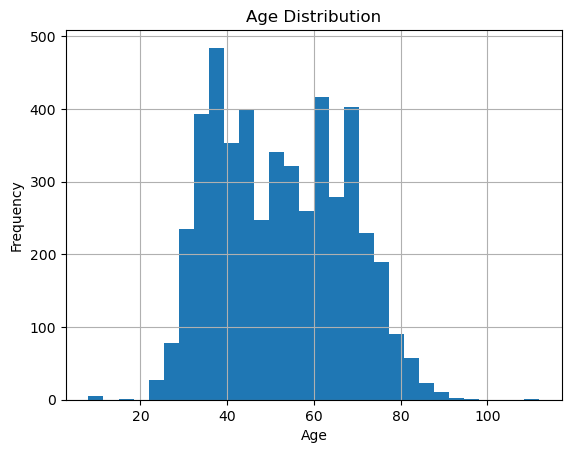

In [37]:
import matplotlib.pyplot as plt

df['age'].dropna().hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [41]:
df_interests = df.copy()

df_interests['interests'] = df_interests['interests'].str.split(',')
df_interests = df_interests.explode('interests')

In [43]:
df_interests['interests'] = (
    df_interests['interests']
    .str.strip()
    .str.lower()
)

Unique interests

In [45]:
df_interests['interests'].nunique()

60

In [47]:
df_interests['interests'].unique()

array(['energie', 'loterij', 'kranten', 'entertainment', 'winactie',
       'cadeau', 'bladen', 'kansspelen', 'goededoelen', 'acties',
       'unknown', 'kortingen', 'onderzoek', 'auto', 'cx80', 'mkb',
       'verzekering', 'auto inruilen', 'mazda', 'elektrisch',
       'zakelijk rijden', 'audi', 'mazda6e', 'ondernemers', 'dacia',
       'bigevent', 'hybrid', 'mercedes', 'toyota', 'lease', 'windows',
       'bank', 'beleggen', 'finance', 'cx60', 'hr', 'cx5', 'bedrijven',
       'it', 'telcom', 'hypotheek', 'centraal beheer', 'mx30', 'cx30',
       'ios', 'android', 'hyundai', 'linux', nan, 'bedrijfswagen',
       'belastingdienst', 'wetgeving', 'zzp', 'zorg', 'overheid',
       'bezorgmaaltijden', 'horeca', 'os x', 'porsche', 'chrome os',
       'mac os'], dtype=object)

In [49]:
df_interests['interests'].value_counts()

interests
bladen              19382
acties              18990
kranten             18536
winactie            17859
cadeau              17491
kortingen           17436
energie             16884
goededoelen         15515
onderzoek           15224
auto                12766
mazda               12091
unknown             12074
lease               12066
zakelijk rijden     12012
elektrisch          11821
auto inruilen       10336
kansspelen          10224
toyota               9783
audi                 9715
dacia                8440
bigevent             8440
entertainment        8375
finance              8102
bank                 7626
beleggen             7519
verzekering          6966
cx60                 6876
loterij              6827
mkb                  6698
ondernemers          6008
cx80                 5558
hybrid               4867
mazda6e              4601
cx30                 3138
mercedes             2868
bedrijven            2644
mx30                 2609
cx5                  2609
wi

In [51]:
df['postcode'] = (
    df['postcode']
    .astype(str)
    .str.upper()
    .str.replace(' ', '', regex=False)
    .str.extract(r'(\d{4}[A-Z]{0,2})')
)

In [55]:
df['postcode'].sample(50)

7038     4041AE
6753     3207VM
3879        NaN
7273     3961XA
16513    6711HX
465         NaN
1086        NaN
9437       8840
17213       NaN
18851       NaN
90          NaN
19984    3351NB
700         NaN
11842    6374TW
9451     8013RV
10725    3071XW
19923    4926HB
7383     3454GB
2939        NaN
14958    1067VN
7848     2548WE
14876    3981EB
14069       NaN
17319       NaN
2514        NaN
567         NaN
724         NaN
1663        NaN
19159       NaN
19424    5653JS
19246    6413RS
18781       NaN
18490       NaN
13403      9450
19697    3615BH
19168    7651GC
3888        NaN
4060        NaN
1911        NaN
11780    8622DE
2735        NaN
18946       NaN
10435      8793
8208     5061CV
12865    1723HS
14588    2525AT
9921     6532SJ
14385    9408HE
7984     9481TB
7972     5981CL
Name: postcode, dtype: object

In [61]:
df['city'] = (
    df['city']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace('null', pd.NA)
)

In [71]:
df['city'] = df['city'].replace('nan', pd.NA)

In [81]:
df['interests'] = df['interests'].str.split(',')

In [83]:
type(df['interests'].iloc[0])

list

In [105]:
df['interests'] = df['interests'].apply(
    lambda x: [i.strip().lower() for i in x] if isinstance(x, list) else []
)

In [107]:
df['n_interests'] = df['interests'].apply(len)

In [113]:
df.head

<bound method NDFrame.head of                              id  gender birth_date postcode  city  \
0      5cb9a38136dd1336b9c528d1    male        NaT      NaN  <NA>   
1      5cb9a38336dd1336b9c537f3  female        NaT      NaN  <NA>   
2      5cb9a38236dd1336b9c52f07    male        NaT      NaN  <NA>   
3      5cb9a38236dd1336b9c53694  female        NaT      NaN  <NA>   
4      5cb9a38636dd1336b9c54e48    male        NaT      NaN  <NA>   
...                         ...     ...        ...      ...   ...   
19995  5c6bed6d5798a7942837bfcd    male        NaT   3815MN  <NA>   
19996  5c6bed715798a7942837dbb0    male 1986-07-09   7553LG  <NA>   
19997  5c6bed725798a7942837e588    male        NaT   2412VF  <NA>   
19998  5c6bed6b5798a7942837b3c3    male        NaT   5632PM  <NA>   
19999  5c6bed715798a7942837dd89  female        NaT   6721GV  <NA>   

                                                mailings  \
0      1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...   
1      1:668,1:692,1: